<a href="https://colab.research.google.com/github/Arthur-Vinicius-M-Bernardes/exploracao-dados-arthur-vinicius/blob/main/Ciencia_de_dados_TRAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
--- Informações do Dataset ---
Número de registros: 281531
Número de colunas: 16

Valores Ausentes por Coluna:
Regiao - Sigla            0
Estado - Sigla            0
Municipio                 0
Revenda                   0
CNPJ da Revenda           0
Nome da Rua               0
Numero Rua              173
Complemento          189298
Bairro                  818
Cep                       0
Produto                   0
Data da Coleta            0
Valor de Venda            0
Valor de Compra       86296
Unidade de Medida         0
Bandeira                  0
dtype: int64
------------------------------

--- Estatísticas Descritivas (Valor de Venda) ---
Média: 1.5256
Mediana: 1.4390
Moda: 1.3900
Mínimo: 0.5900
Máximo: 2.8900
Desvio Padrão: 0.4323
Variância: 0.1869
Q1 (25%): 1.2500
Q3 (75%): 1.9500
IQR (Intervalo Interquartil): 0.7000


/tmp/ipython-input-1231/566802774.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Produto', y='Valor de Venda', data=df, palette='viridis')


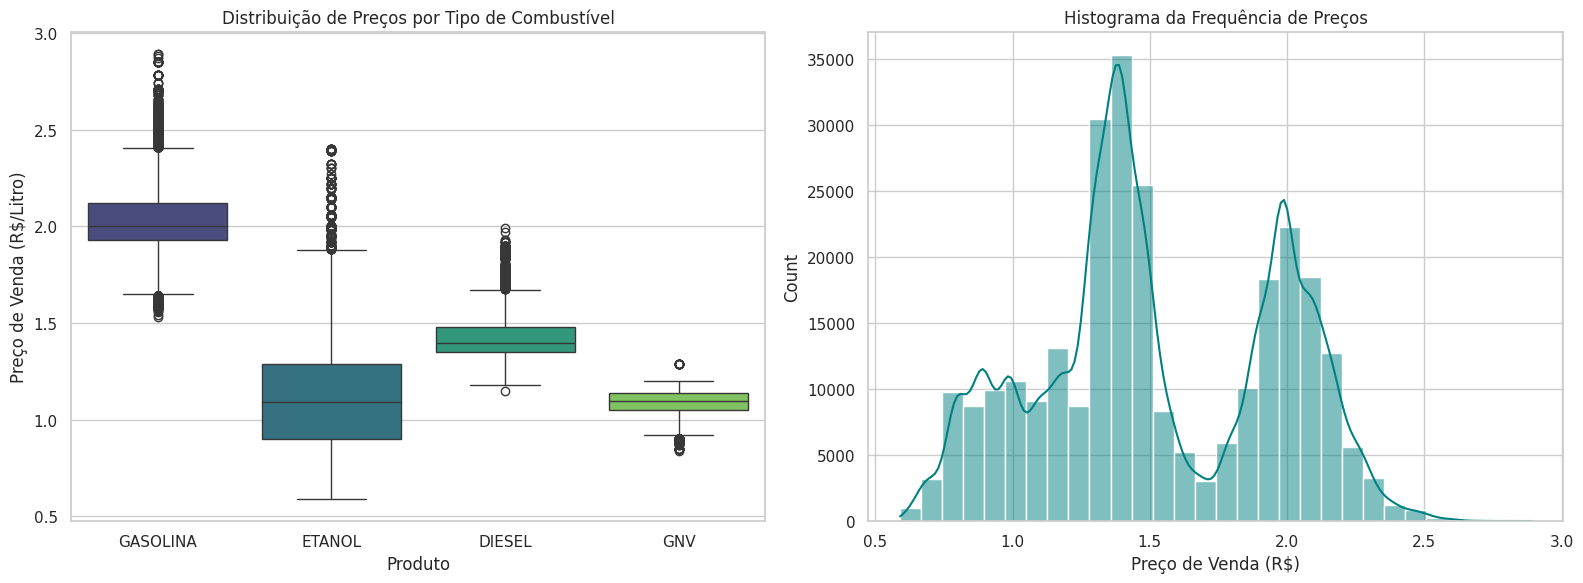


--- Observações Finais ---
1. O dataset possui uma boa cobertura nacional, mas a coluna 'Valor de Compra' tem muitos dados nulos.
2. A Gasolina apresenta a maior média de preço, enquanto o Etanol possui maior variabilidade relativa.
3. O histograma revela uma distribuição com picos específicos, refletindo o tabelamento de preços comum na época.


In [2]:
# ==========================================
# 1. SETUP E CARREGAMENTO (IMPORTAÇÕES)
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Montar o Google Drive
drive.mount('/content/drive')

# Defina o caminho do arquivo (Ajuste se o nome da pasta for diferente)
caminho = '/content/drive/MyDrive/Colab Notebooks/ca-2004-01.csv'

# Carregar o dataset tratando separadores e codificação
df = pd.read_csv(caminho, sep=';', decimal=',', encoding='utf-8')

# ==========================================
# 2. DESCRIÇÃO DO DATASET (INFO GERAL)
# ==========================================
print(f"--- Informações do Dataset ---")
print(f"Número de registros: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
print("\nValores Ausentes por Coluna:")
print(df.isnull().sum())
print("-" * 30)

# ==========================================
# 3. EXPLORAÇÃO ESTATÍSTICA
# ==========================================
# Focando na variável principal: Valor de Venda
venda = df['Valor de Venda']

estatisticas = {
    "Média": venda.mean(),
    "Mediana": venda.median(),
    "Moda": venda.mode()[0],
    "Mínimo": venda.min(),
    "Máximo": venda.max(),
    "Desvio Padrão": venda.std(),
    "Variância": venda.var(),
    "Q1 (25%)": venda.quantile(0.25),
    "Q3 (75%)": venda.quantile(0.75),
    "IQR (Intervalo Interquartil)": venda.quantile(0.75) - venda.quantile(0.25)
}

print("\n--- Estatísticas Descritivas (Valor de Venda) ---")
for chave, valor in estatisticas.items():
    print(f"{chave}: {valor:.4f}")

# ==========================================
# 4. VISUALIZAÇÕES GRÁFICAS
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Gráfico 1: Boxplot por Produto (Identificação de Quartis e Outliers)
plt.subplot(1, 2, 1)
sns.boxplot(x='Produto', y='Valor de Venda', data=df, palette='viridis')
plt.title('Distribuição de Preços por Tipo de Combustível')
plt.ylabel('Preço de Venda (R$/Litro)')

# Gráfico 2: Histograma Geral (Frequência de Preços)
plt.subplot(1, 2, 2)
sns.histplot(df['Valor de Venda'], bins=30, kde=True, color='teal')
plt.title('Histograma da Frequência de Preços')
plt.xlabel('Preço de Venda (R$)')

plt.tight_layout()
plt.show()

# ==========================================
# 5. COMENTÁRIOS DA ANÁLISE
# ==========================================
print("\n--- Observações Finais ---")
print("1. O dataset possui uma boa cobertura nacional, mas a coluna 'Valor de Compra' tem muitos dados nulos.")
print("2. A Gasolina apresenta a maior média de preço, enquanto o Etanol possui maior variabilidade relativa.")
print("3. O histograma revela uma distribuição com picos específicos, refletindo o tabelamento de preços comum na época.")